In [ ]:
import torch
import numpy as np
from data.simulations import make_gaussian_to_moons
from data.space import SpaceManager
from models.baselines import (
    BaselineModel,
    NoEffectBaseline,
    ContextMeanBaseline,
    PerturbMeanBaseline,
    DecoderOnlyBaseline,
    AdditiveBaseline,
)
from evaluation.metrics import compute_mmd, compute_energy_distance, compute_wasserstein_distance, compute_cosine_log_fc
import anndata as ad
from models.flow import CondFlow, ConditionEncoder, sample_ode
from models.mean_flow import CondMeanFlow

# set up data and space
adata = ad.read_h5ad("gaussian_to_moons.h5ad")
space = SpaceManager(mode="raw", n_hvgs=None)
space.fit(adata)

# extract control and perturbed data
is_ctrl = adata.obs["vehicle"] == 1.0
is_pert_any = adata.obs["vehicle"] == 0.0  # both moons

x_ctrl = torch.from_numpy(adata[is_ctrl].X).float()
x_pert_all = torch.from_numpy(adata[is_pert_any].X).float()

print(f"Control cells: {x_ctrl.shape[0]}, Perturbed cells: {x_pert_all.shape[0]}")

# load models, each model needs its own ConditionEncoder instance,
# otherwise load_state_dict on the second model overwrites the first's encoder weights
covariate_dicts = {
    "perturbation_num_categories": 3,  # 0: control, 1: pert1, 2: pert2
    "perturbation_covariates": {},
    "sample_covariates": {},
}

fm_cond_enc = ConditionEncoder(covariate_dicts=covariate_dicts, embedding_dim=16)
fm_model = CondFlow(input_dim=2, output_dim=2, hidden_dim=64, hidden_layers=3, cond_encoder=fm_cond_enc)
fm_model.load_state_dict(torch.load("toy_fm_model.pt"))
fm_model.eval()

ode_cond_enc = ConditionEncoder(covariate_dicts=covariate_dicts, embedding_dim=16)
ode_model = CondFlow(input_dim=2, output_dim=2, hidden_dim=64, hidden_layers=3, cond_encoder=ode_cond_enc)
ode_model.load_state_dict(torch.load("toy_ode_model.pt"))
ode_model.eval()

mf_cond_enc = ConditionEncoder(covariate_dicts=covariate_dicts, embedding_dim=16)
mf_model = CondMeanFlow(input_dim=2, output_dim=2, hidden_dim=64, hidden_layers=3, cond_encoder=mf_cond_enc)
mf_model.load_state_dict(torch.load("toy_mf_model.pt"))
mf_model.eval()


class FlowMatchingBaseline(BaselineModel):
    def __init__(self, fm_model):
        super().__init__()
        self.fm_model = fm_model

    def fit(self, x_ctrl, x_pert_all, cond_pert_all):
        pass

    def sample(self, x_ctrl, cond_pert):
        with torch.no_grad():
            x_pred = sample_ode(self.fm_model, x_ctrl, cond_pert)
        return x_pred


class NeuralODEBaseline(BaselineModel):
    def __init__(self, ode_model):
        super().__init__()
        self.ode_model = ode_model

    def fit(self, x_ctrl, x_pert_all, cond_pert_all):
        pass

    def sample(self, x_ctrl, cond_pert):
        with torch.no_grad():
            # Use dopri5 for consistency with training
            x_pred = sample_ode(self.ode_model, x_ctrl, cond_pert, method="dopri5")
        return x_pred


class MeanFlowBaseline(BaselineModel):
    def __init__(self, mf_model):
        super().__init__()
        self.mf_model = mf_model

    def fit(self, x_ctrl, x_pert_all, cond_pert_all):
        pass

    def sample(self, x_ctrl, cond_pert):
        with torch.no_grad():
            x_pred = self.mf_model.sample_one_step(x_ctrl, cond_pert)
        return x_pred


def make_cond_dict(pert_ids, n):
    return {"perturbations": pert_ids, "perturbation_covariates": {}, "sample_covariates": {}}


# Condition batch for ALL perturbed cells (both moons, perturbation IDs 1 and 2)
pert_ids_all = torch.tensor(adata[is_pert_any].obs["perturbation"].astype(int).values)
cond_pert_all = make_cond_dict(pert_ids_all, len(pert_ids_all))

# Evaluation targets per perturbation
is_pert1 = adata.obs["perturbation"] == 1.0
is_pert2 = adata.obs["perturbation"] == 2.0
x_pert1 = torch.from_numpy(adata[is_pert1].X).float()
x_pert2 = torch.from_numpy(adata[is_pert2].X).float()

# Query conditions: one ConditionBatch per perturbation, each with n_ctrl entries
n_ctrl = x_ctrl.shape[0]
cond_pert1 = make_cond_dict(torch.ones(n_ctrl, dtype=torch.long), n_ctrl)
cond_pert2 = make_cond_dict(torch.full((n_ctrl,), 2, dtype=torch.long), n_ctrl)

eval_perts = [
    ("Pert 1", cond_pert1, x_pert1),
    ("Pert 2", cond_pert2, x_pert2),
]

# 3. Define and Fit Baselines
baselines = {
    "NoEffect": NoEffectBaseline(),
    "ContextMean": ContextMeanBaseline(),
    "PerturbationMean": PerturbMeanBaseline(),
    "Decoder": DecoderOnlyBaseline(input_dim=2, output_dim=2),
    "Additive": AdditiveBaseline(),
    "FlowMatching": FlowMatchingBaseline(fm_model),
    "NeuralODE": NeuralODEBaseline(ode_model),
    "MeanFlow (1-NFE)": MeanFlowBaseline(mf_model),
}

results = {}
for name, model in baselines.items():
    model.fit(x_ctrl, x_pert_all, cond_pert_all)
    results[name] = {}
    for pert_name, cond, x_pert_gt in eval_perts:
        x_pred = model.sample(x_ctrl, cond)
        results[name][pert_name] = {
            "MMD": compute_mmd(x_pred, x_pert_gt),
            "Energy": compute_energy_distance(x_pred, x_pert_gt),
            "W2": compute_wasserstein_distance(x_pred, x_pert_gt),
            "CosineLogFC": compute_cosine_log_fc(x_pred, x_pert_gt, x_ctrl),
            "x_pred": x_pred.numpy(),
            "x_gt": x_pert_gt.numpy(),
        }

# print results
header = f"{'Baseline':<18} | {'Perturbation':<12} | {'MMD':<10} | {'Energy':<10} | {'W2':<10} | {'CosineLogFC':<12}"
print(header)
print("-" * len(header))
for name, pert_results in results.items():
    for pert_name, scores in pert_results.items():
        print(
            f"{name:<18} | {pert_name:<12} | {scores['MMD']:<10.4f} | {scores['Energy']:<10.4f} | {scores['W2']:<10.4f} | {scores['CosineLogFC']:<12.4f}"
        )

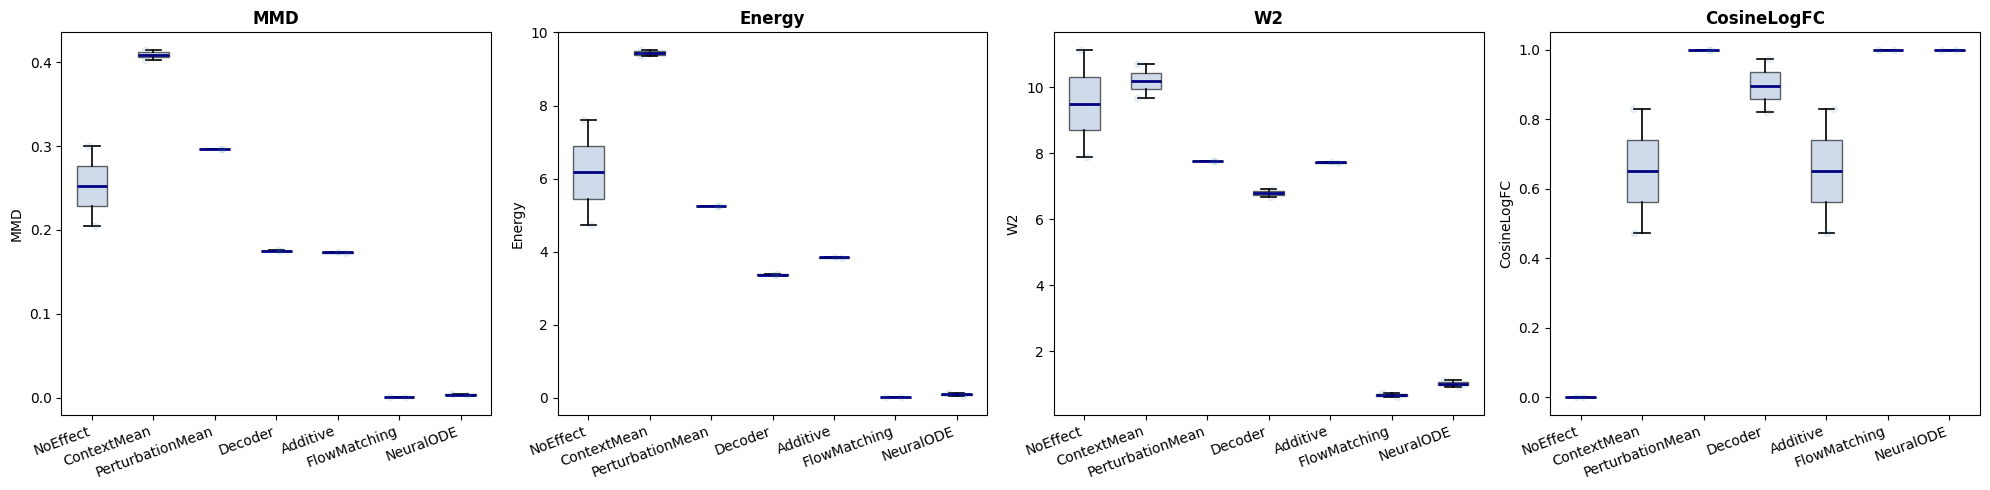

In [8]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ["MMD", "Energy", "W2", "CosineLogFC"]
baseline_names = list(results.keys())
all_pd_strs = list(next(iter(results.values())).keys())

fig, axes = plt.subplots(1, len(metrics), figsize=(5 * len(metrics), 5))

for ax, metric in zip(axes, metrics):
    data_per_baseline = [[results[name][pd_str][metric] for pd_str in all_pd_strs] for name in baseline_names]
    positions = np.arange(len(baseline_names))

    ax.boxplot(
        data_per_baseline,
        positions=positions,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor="lightsteelblue", alpha=0.6),
        medianprops=dict(color="navy", linewidth=2),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker=""),
    )

    dot_rng = np.random.default_rng(0)
    for i, vals in enumerate(data_per_baseline):
        jitter = dot_rng.uniform(-0.15, 0.15, size=len(vals))
        ax.scatter(positions[i] + jitter, vals, s=20, alpha=0.1, color="steelblue", zorder=3)

    ax.set_title(metric, fontweight="bold")
    ax.set_xticks(positions)
    ax.set_xticklabels(baseline_names, rotation=20, ha="right")
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()

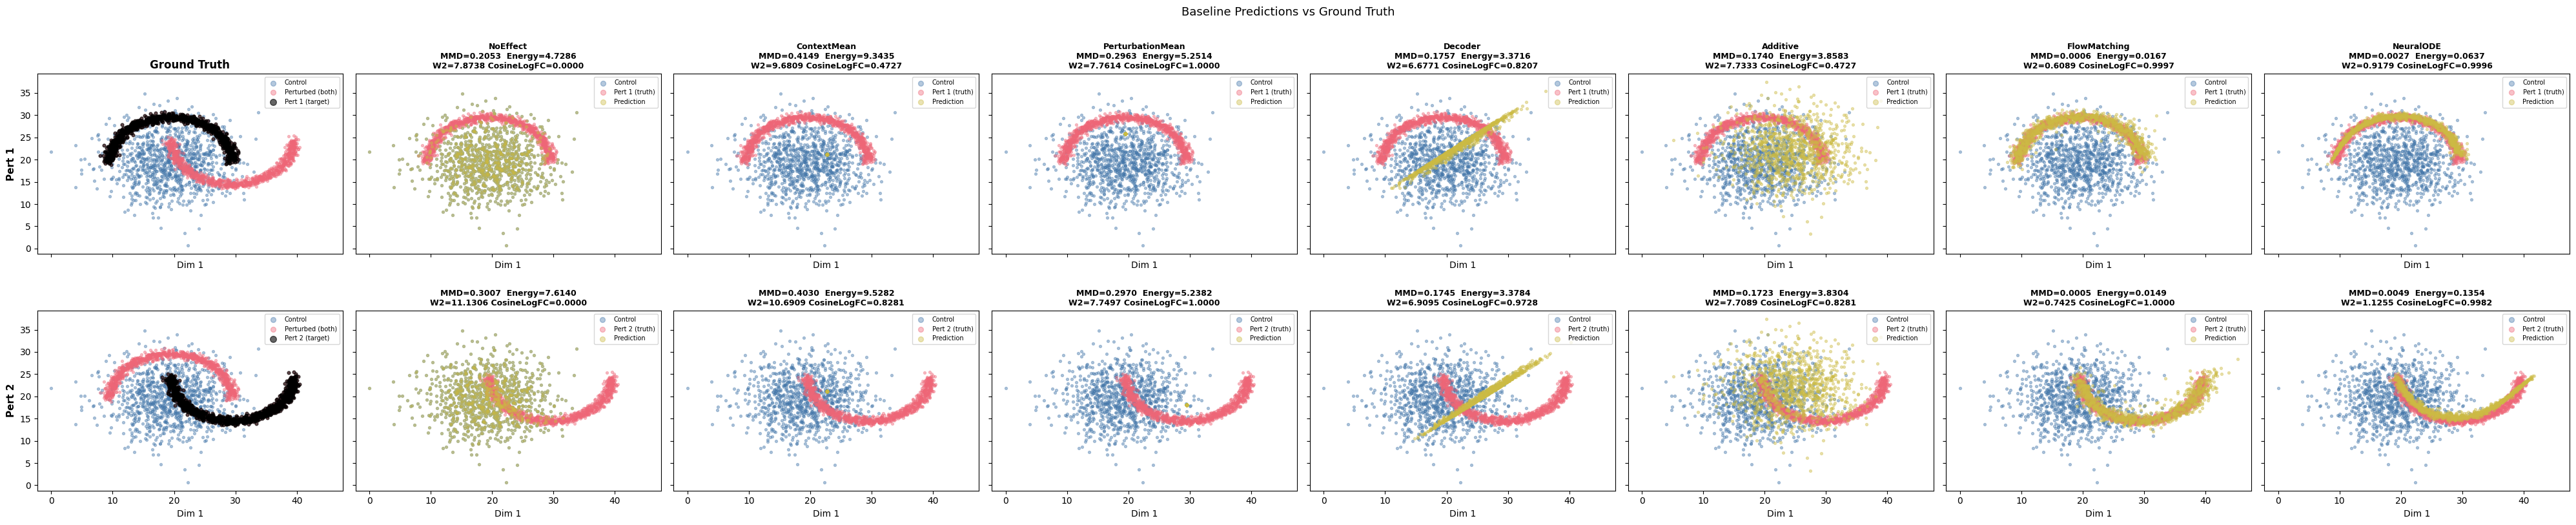

In [ ]:
import matplotlib.pyplot as plt

x_ctrl_np = x_ctrl.numpy()
x_pert_all_np = x_pert_all.numpy()

pert_names = list(next(iter(results.values())).keys())  # ["Pert 1", "Pert 2"]
baseline_names = list(results.keys())
n_rows = len(pert_names)
n_cols = len(baseline_names) + 1  # +1 for ground truth

COLORS = {"control": "#4477AA", "perturbation (truth)": "#EE6677", "prediction": "#CCBB44"}
alpha = 0.4
s = 8

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows), sharex=True, sharey=True)

for row, pert_name in enumerate(pert_names):
    # Ground truth column: control + both moons
    ax = axes[row, 0]
    ax.scatter(x_ctrl_np[:, 0], x_ctrl_np[:, 1], c=COLORS["Control"], s=s, alpha=alpha, label="Control")
    ax.scatter(
        x_pert_all_np[:, 0],
        x_pert_all_np[:, 1],
        c=COLORS["perturbation (truth)"],
        s=s,
        alpha=alpha,
        label="perturbed (both)",
    )
    gt_np = next(iter(results.values()))[pert_name]["x_gt"]
    ax.scatter(gt_np[:, 0], gt_np[:, 1], c="black", s=s + 4, alpha=0.6, label=f"{pert_name} (target)", zorder=3)
    if row == 0:
        ax.set_title("ground Truth", fontsize=12, fontweight="bold")
    ax.set_ylabel(pert_name, fontsize=11, fontweight="bold")
    ax.set_xlabel("dim 1")
    ax.legend(loc="upper right", markerscale=2, fontsize=7)

    # One column per baseline
    for col, name in enumerate(baseline_names):
        ax = axes[row, col + 1]
        scores = results[name][pert_name]
        ax.scatter(x_ctrl_np[:, 0], x_ctrl_np[:, 1], c=COLORS["control"], s=s, alpha=alpha, label="control")
        ax.scatter(
            scores["x_gt"][:, 0],
            scores["x_gt"][:, 1],
            c=COLORS["perturbation (truth)"],
            s=s,
            alpha=alpha,
            label=f"{pert_name} (truth)",
        )
        ax.scatter(
            scores["x_pred"][:, 0], scores["x_pred"][:, 1], c=COLORS["prediction"], s=s, alpha=alpha, label="prediction"
        )
        if row == 0:
            ax.set_title(name, fontsize=12, fontweight="bold")
        ax.set_title(
            f"{name if row == 0 else ''}\nMMD={scores['MMD']:.4f}  Energy={scores['Energy']:.4f}\nW2={scores['W2']:.4f} CosineLogFC={scores['CosineLogFC']:.4f}",
            fontsize=9,
            fontweight="bold",
        )
        ax.set_xlabel("dim 1")
        ax.legend(loc="upper right", markerscale=2, fontsize=7)

plt.suptitle("baseline predictions vs ground truth", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()
